# Phase A.2 - Analyse des Reviewers

Ce notebook contient les analyses suivantes:
1. Les "gros reviewers" sont-ils plus sévères que les autres?
2. Est-ce que les utilisateurs expérimentés ont tendance à faire des reviews plus détaillées?

## 0. Import et chargement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from scipy import stats
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# Charger les données
DATA_DIR = Path('../data')

def load_json_lines(file_path, n_lines=None):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if n_lines and i >= n_lines:
                break
            data.append(json.loads(line))
            if (i + 1) % 100000 == 0:
                print(f"  Chargé {i + 1:,} lignes...")
    return pd.DataFrame(data)

SAMPLE_SIZE = None

print("Chargement des données...")
df_reviews = load_json_lines(DATA_DIR / 'raw' / 'yelp_academic_reviews4students.jsonl')
df_users = load_json_lines(DATA_DIR / 'raw'  / 'yelp_academic_dataset_user4students.jsonl')

print(f"\n✓ {len(df_reviews):,} reviews chargées")
print(f"✓ {len(df_users):,} users chargés")

Chargement des données...
  Chargé 100,000 lignes...
  Chargé 200,000 lignes...
  Chargé 300,000 lignes...
  Chargé 400,000 lignes...
  Chargé 500,000 lignes...
  Chargé 600,000 lignes...
  Chargé 700,000 lignes...
  Chargé 800,000 lignes...
  Chargé 900,000 lignes...
  Chargé 1,000,000 lignes...
  Chargé 100,000 lignes...
  Chargé 200,000 lignes...
  Chargé 300,000 lignes...
  Chargé 400,000 lignes...
  Chargé 500,000 lignes...

✓ 1,000,000 reviews chargées
✓ 558,095 users chargés


In [5]:
# Préparer les données
df_reviews['text_length'] = df_reviews['text'].str.len()
df_reviews['word_count'] = df_reviews['text'].str.split().str.len()

print("Colonnes disponibles dans users:")
print(df_users.columns.tolist())

Colonnes disponibles dans users:
['user_id', 'name', 'review_count', 'yelping_since', 'useful', 'funny', 'cool', 'elite', 'friends', 'fans', 'average_stars', 'compliment_hot', 'compliment_more', 'compliment_profile', 'compliment_cute', 'compliment_list', 'compliment_note', 'compliment_plain', 'compliment_cool', 'compliment_funny', 'compliment_writer', 'compliment_photos']


## 1. Les "gros reviewers" sont-ils plus sévères?

### Méthodologie
Pour répondre à cette question, nous agrégeons les données par utilisateur (`user_id`). Nous calculons la note moyenne donnée par chaque utilisateur ainsi que son nombre total de reviews.
Nous classons ensuite les utilisateurs en catégories (Occasionnel à Expert) pour comparer leurs comportements de notation de manière plus granulaire.

Nous nous intéressons aux reviewers et à leurs notes. Nous souhaitons analyser si les utilisateurs ayant attribué beaucoup de notes sont plus sévères, c'est-à-dire, s'ils attribuent des notes généralement moins bonnes que les utilisateurs ayant attribué peu de notes.

In [7]:
# Calculer les statistiques par utilisateur
user_stats = df_reviews.groupby('user_id').agg({
    'stars': ['mean', 'count', 'std'],
    'text_length': 'mean',
    'word_count': 'mean'
}).reset_index()

user_stats.columns = ['user_id', 'avg_rating', 'review_count', 'rating_std', 
                      'avg_text_length', 'avg_word_count']

print(f"Nombre d'utilisateurs analysés: {len(user_stats):,}")
print(f"\nStatistiques sur le nombre de reviews par utilisateur:")
print(user_stats['review_count'].describe())

Nombre d'utilisateurs analysés: 558,099

Statistiques sur le nombre de reviews par utilisateur:
count    558099.000000
mean          1.791797
std           3.342478
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         458.000000
Name: review_count, dtype: float64


In [8]:
# Catégoriser les reviewers par activité
user_stats['reviewer_type'] = pd.cut(user_stats['review_count'], 
                                      bins=[0, 5, 20, 50, 100, float('inf')],
                                      labels=['Occasionnel (1-5)', 'Régulier (6-20)', 
                                             'Actif (21-50)', 'Très actif (51-100)', 
                                             'Expert (100+)'])

print("Distribution des utilisateurs par type:")
print(user_stats['reviewer_type'].value_counts().sort_index())

Distribution des utilisateurs par type:
reviewer_type
Occasionnel (1-5)      537367
Régulier (6-20)         18324
Actif (21-50)            2061
Très actif (51-100)       287
Expert (100+)              60
Name: count, dtype: int64


In [9]:
# Analyser la note moyenne par type de reviewer
reviewer_analysis = user_stats.groupby('reviewer_type').agg({
    'avg_rating': ['mean', 'median', 'std'],
    'user_id': 'count'
}).round(3)

print("Analyse: Note moyenne par type de reviewer")
print(reviewer_analysis)

Analyse: Note moyenne par type de reviewer
                    avg_rating               user_id
                          mean median    std   count
reviewer_type                                       
Occasionnel (1-5)        3.680  4.000  1.532  537367
Régulier (6-20)          3.852  3.917  0.651   18324
Actif (21-50)            3.862  3.885  0.422    2061
Très actif (51-100)      3.837  3.850  0.371     287
Expert (100+)            3.871  3.893  0.346      60


### Visualisation de la sévérité
Pour observer visuellement si les experts notent plus durement, nous utilisons deux types de graphiques :
1.  **Box Plot** : Pour comparer les médianes et la dispersion (quartiles) des notes entre les catégories.
2.  **Violin Plot** : Pour voir la distribution complète et la densité des notes (où se concentrent la plupart des avis).

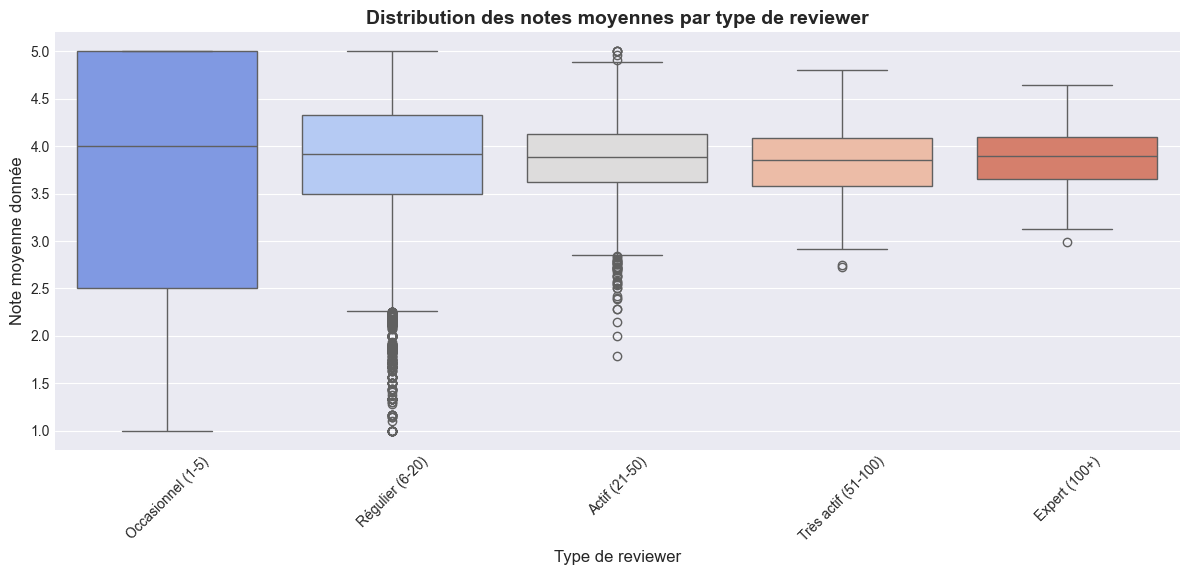

In [11]:
# Visualisation 1: Relation entre nombre de reviews et note moyenne
fig, ax2 = plt.subplots(figsize=(12, 6))

# Box plot par catégorie
sns.boxplot(y='avg_rating', x='reviewer_type', data=user_stats, palette='coolwarm', ax=ax2)
ax2.set_xlabel('Type de reviewer', fontsize=12)
ax2.set_ylabel('Note moyenne donnée', fontsize=12)
ax2.set_title('Distribution des notes moyennes par type de reviewer', 
             fontsize=14, fontweight='bold')
plt.suptitle('')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

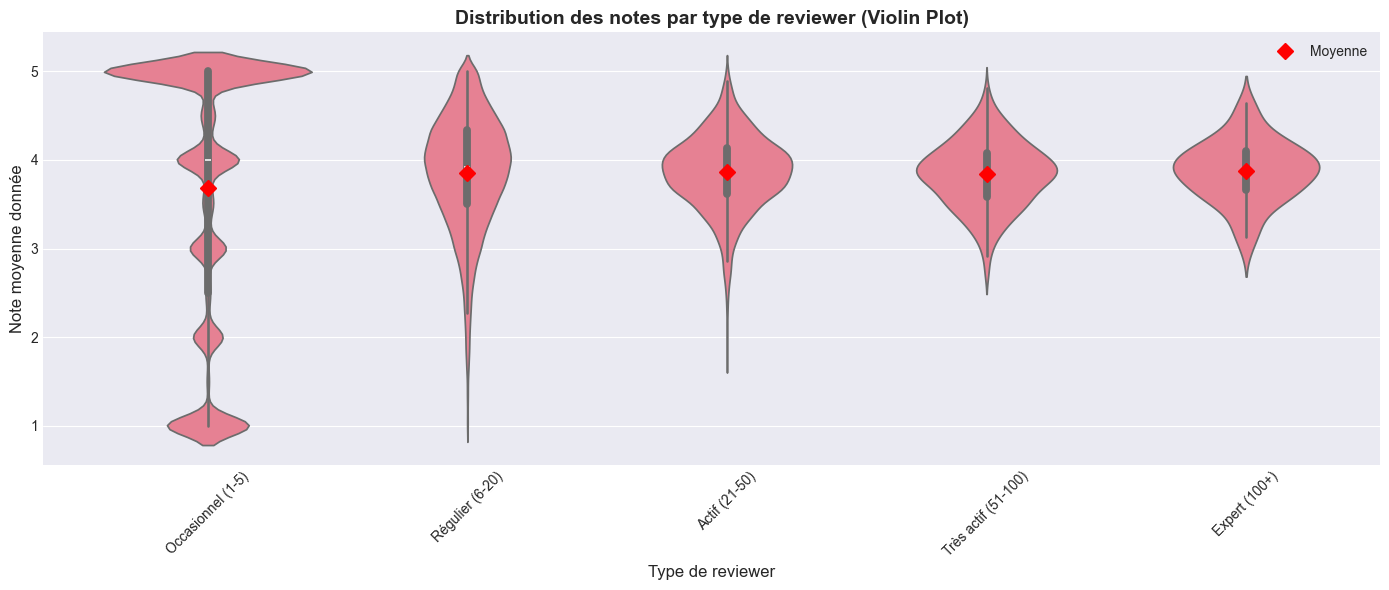

In [12]:
# Visualisation 2: Violin plot
fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=user_stats, x='reviewer_type', y='avg_rating', ax=ax)
ax.set_xlabel('Type de reviewer', fontsize=12)
ax.set_ylabel('Note moyenne donnée', fontsize=12)
ax.set_title('Distribution des notes par type de reviewer (Violin Plot)', 
            fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# Ajouter les moyennes
means = user_stats.groupby('reviewer_type')['avg_rating'].mean()
positions = range(len(means))
ax.plot(positions, means, 'D', color='red', markersize=8, label='Moyenne', zorder=5)
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
# Test statistique: Comparer experts vs occasionnels
from scipy.stats import mannwhitneyu

casual_ratings = user_stats[user_stats['reviewer_type'] == 'Occasionnel (1-5)']['avg_rating']
expert_ratings = user_stats[user_stats['reviewer_type'] == 'Expert (100+)']['avg_rating']

if len(expert_ratings) > 0:
    statistic, p_value = mannwhitneyu(casual_ratings, expert_ratings, alternative='two-sided')
    
    print(f"Comparaison Occasionnels vs Experts:")
    print(f"Moyenne occasionnels: {casual_ratings.mean():.3f}")
    print(f"Moyenne experts: {expert_ratings.mean():.3f}")
    print(f"\nTest de Mann-Whitney U:")
    print(f"Statistique: {statistic:.2f}")
    print(f"P-value: {p_value:.2e}")
    
    if p_value < 0.05:
        print("\n→ Différence SIGNIFICATIVE")
        if expert_ratings.mean() < casual_ratings.mean():
            print("→ Les experts sont PLUS SÉVÈRES")
        else:
            print("→ Les experts sont MOINS SÉVÈRES")
    else:
        print("\n→ Pas de différence significative")
else:
    print("Pas assez d'experts dans l'échantillon")

Comparaison Occasionnels vs Experts:
Moyenne occasionnels: 3.680
Moyenne experts: 3.871

Test de Mann-Whitney U:
Statistique: 18787155.00
P-value: 1.96e-02

→ Différence SIGNIFICATIVE
→ Les experts sont MOINS SÉVÈRES


### Interprétation - Sévérité des reviewers
Les résultats montrent une tendance intéressante :
* **Moyenne des notes** : Contrairement à l'idée reçue, les experts (plus de 100 reviews) ont une note moyenne plus élevée (~3.87) que les utilisateurs occasionnels (~3.68).
* **Test de Mann-Whitney** : La p-value est significative ($p < 0.05$), confirmant que cette différence n'est pas due au hasard.
* **Conclusion** : Les "gros reviewers" ne sont pas plus sévères. Au contraire, ils semblent attribuer des notes plus généreuses ou sont plus enclins à partager des expériences positives. Plusieurs hypothèses peuvent expliquer cela : une meilleure sélection des établissements fréquentés ou une habitude de valoriser les points positifs.

## 2. Les utilisateurs expérimentés font-ils des reviews plus détaillées?

In [16]:
# Analyser la longueur des reviews par type de reviewer
length_analysis = user_stats.groupby('reviewer_type').agg({
    'avg_text_length': ['mean', 'median', 'std'],
    'avg_word_count': ['mean', 'median', 'std'],
    'user_id': 'count'
}).round(2)

print("Analyse: Longueur des reviews par type de reviewer")
print(length_analysis)

Analyse: Longueur des reviews par type de reviewer
                    avg_text_length                 avg_word_count          \
                               mean  median     std           mean  median   
reviewer_type                                                                
Occasionnel (1-5)            507.12  367.00  468.39          93.66   68.00   
Régulier (6-20)              639.35  557.84  361.59         117.93  103.37   
Actif (21-50)                787.82  732.08  357.70         145.27  135.47   
Très actif (51-100)          891.30  812.65  399.80         164.49  151.19   
Expert (100+)               1027.57  878.81  541.54         187.59  160.99   

                           user_id  
                       std   count  
reviewer_type                       
Occasionnel (1-5)    87.47  537367  
Régulier (6-20)      66.34   18324  
Actif (21-50)        65.37    2061  
Très actif (51-100)  73.23     287  
Expert (100+)        96.81      60  


### Visualisation de la longueur et corrélation
Nous explorons ici la relation entre le volume de contribution et la longueur des avis. 
Le coefficient de corrélation de Spearman est privilégié car nous ne supposons pas nécessairement une relation linéaire, et nos données (nombre de reviews) suivent une distribution très étalée.

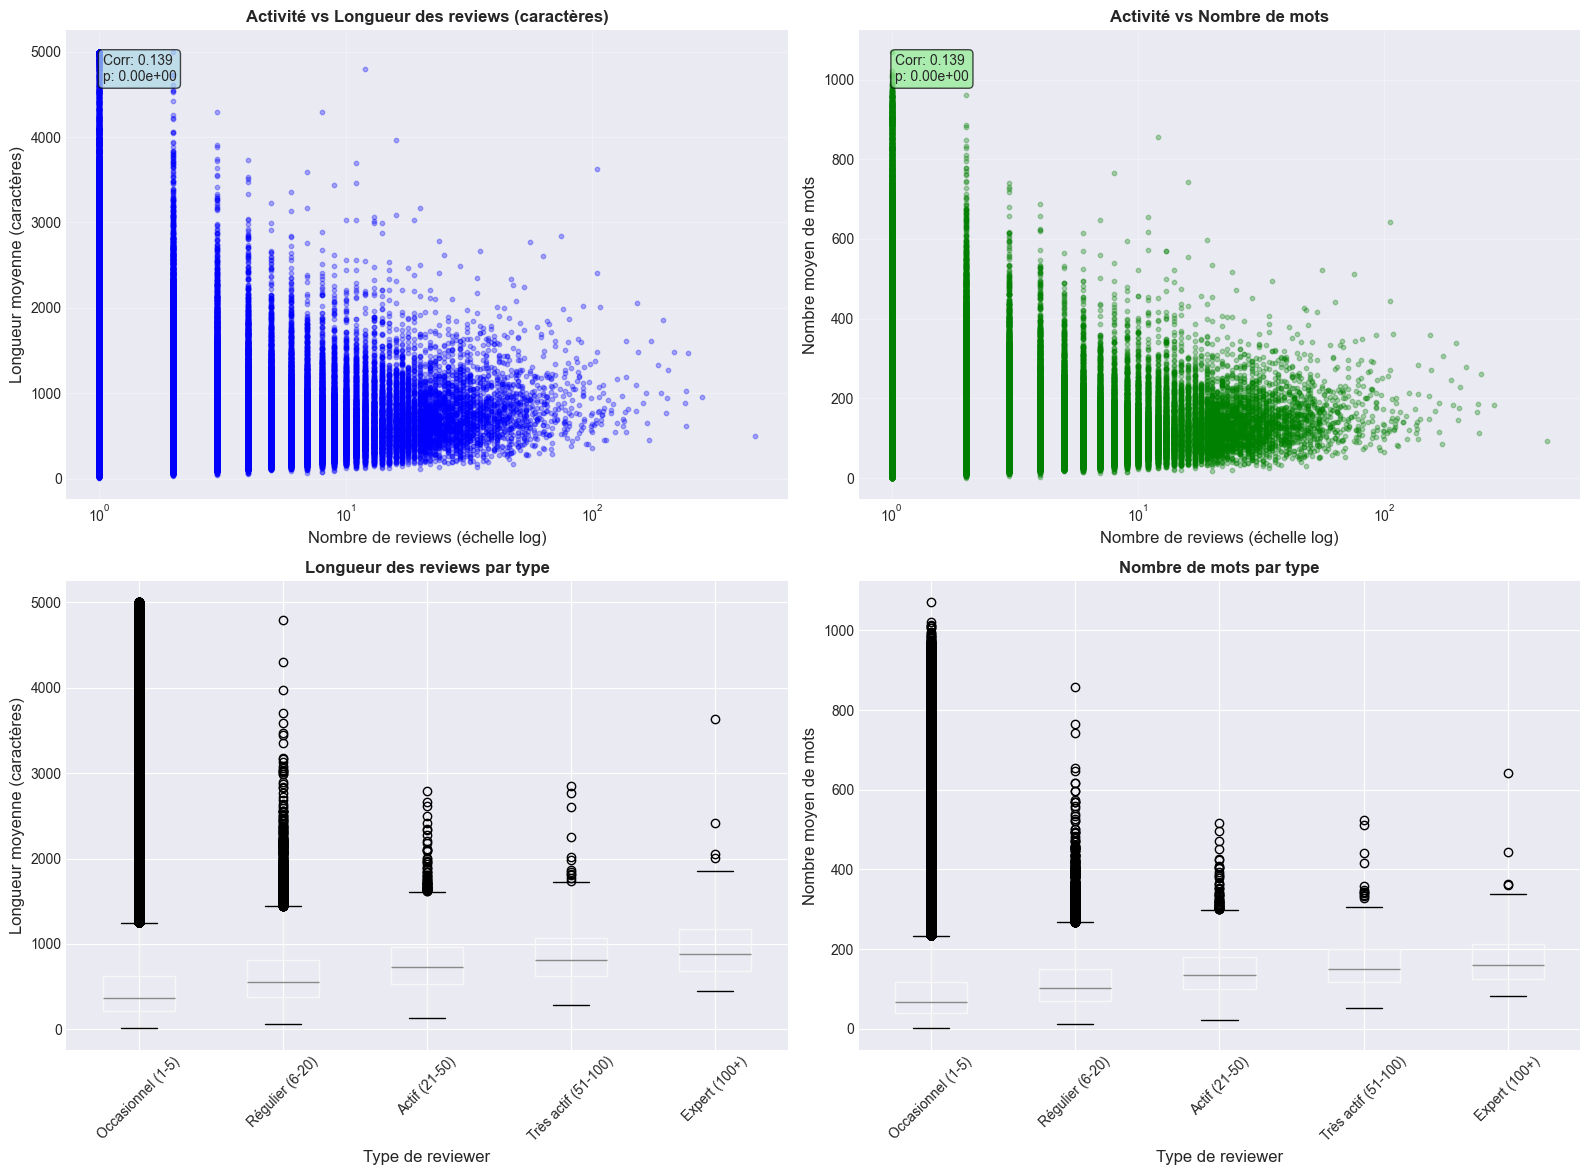

In [13]:
# Visualisation: Scatter plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Nombre de reviews vs longueur moyenne (caractères)
ax1.scatter(user_stats['review_count'], 
           user_stats['avg_text_length'], 
           alpha=0.3, s=10, c='blue')
ax1.set_xscale('log')
ax1.set_xlabel('Nombre de reviews (échelle log)', fontsize=12)
ax1.set_ylabel('Longueur moyenne (caractères)', fontsize=12)
ax1.set_title('Activité vs Longueur des reviews (caractères)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

corr1, p1 = spearmanr(user_stats['review_count'], user_stats['avg_text_length'])
ax1.text(0.05, 0.95, f'Corr: {corr1:.3f}\np: {p1:.2e}',
        transform=ax1.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# 2. Nombre de reviews vs nombre de mots moyen
ax2.scatter(user_stats['review_count'], 
           user_stats['avg_word_count'], 
           alpha=0.3, s=10, c='green')
ax2.set_xscale('log')
ax2.set_xlabel('Nombre de reviews (échelle log)', fontsize=12)
ax2.set_ylabel('Nombre moyen de mots', fontsize=12)
ax2.set_title('Activité vs Nombre de mots', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

corr2, p2 = spearmanr(user_stats['review_count'], user_stats['avg_word_count'])
ax2.text(0.05, 0.95, f'Corr: {corr2:.3f}\np: {p2:.2e}',
        transform=ax2.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# 3. Box plot - longueur moyenne en caractères
user_stats.boxplot(column='avg_text_length', by='reviewer_type', ax=ax3)
ax3.set_xlabel('Type de reviewer', fontsize=12)
ax3.set_ylabel('Longueur moyenne (caractères)', fontsize=12)
ax3.set_title('Longueur des reviews par type', fontsize=12, fontweight='bold')
plt.suptitle('')
ax3.tick_params(axis='x', rotation=45)

# 4. Box plot - nombre moyen de mots
user_stats.boxplot(column='avg_word_count', by='reviewer_type', ax=ax4)
ax4.set_xlabel('Type de reviewer', fontsize=12)
ax4.set_ylabel('Nombre moyen de mots', fontsize=12)
ax4.set_title('Nombre de mots par type', fontsize=12, fontweight='bold')
plt.suptitle('')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

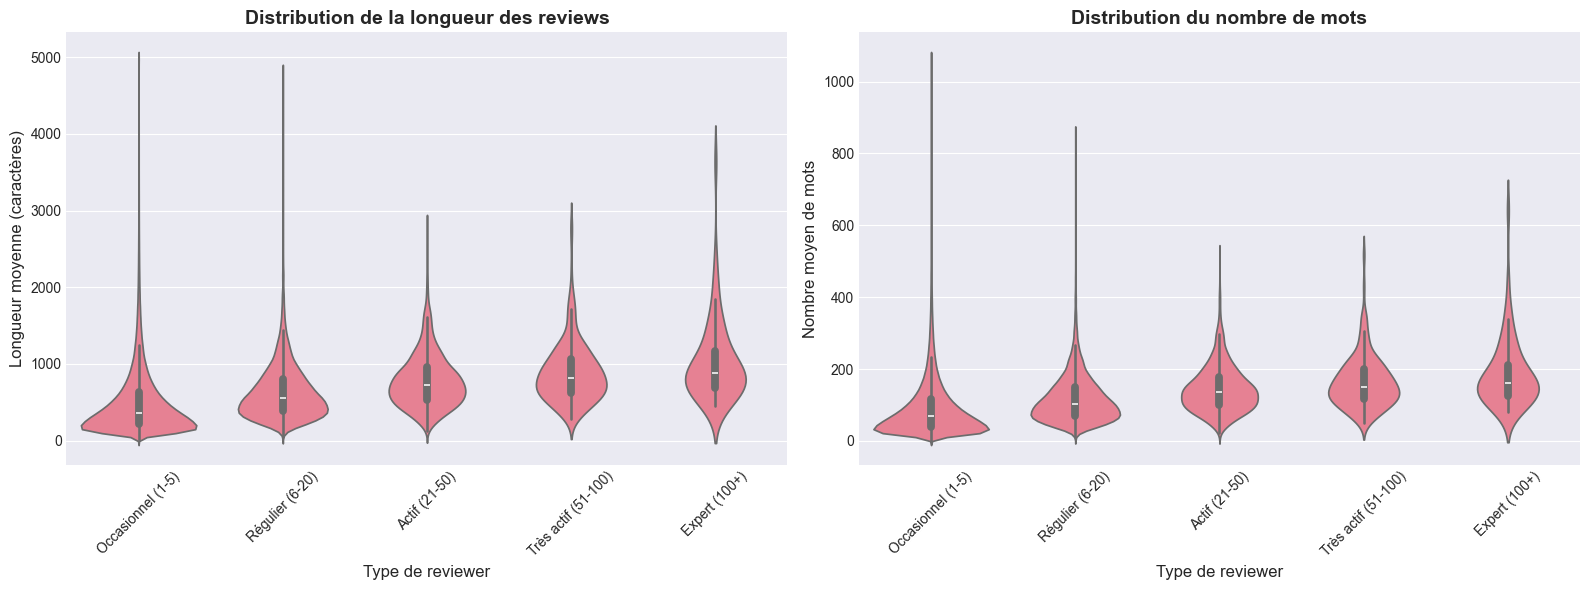

In [ ]:
# Violin plots pour une meilleure visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=user_stats, x='reviewer_type', y='avg_text_length', ax=ax1)
ax1.set_xlabel('Type de reviewer', fontsize=12)
ax1.set_ylabel('Longueur moyenne (caractères)', fontsize=12)
ax1.set_title('Distribution de la longueur des reviews', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

sns.violinplot(data=user_stats, x='reviewer_type', y='avg_word_count', ax=ax2)
ax2.set_xlabel('Type de reviewer', fontsize=12)
ax2.set_ylabel('Nombre moyen de mots', fontsize=12)
ax2.set_title('Distribution du nombre de mots', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../../figures/reviewer_detail_violin.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Test statistique: Comparer la longueur des reviews
casual_length = user_stats[user_stats['reviewer_type'] == 'Occasionnel (1-5)']['avg_word_count']
expert_length = user_stats[user_stats['reviewer_type'] == 'Expert (100+)']['avg_word_count']

if len(expert_length) > 0:
    statistic, p_value = mannwhitneyu(casual_length, expert_length, alternative='two-sided')
    
    print(f"Comparaison longueur reviews: Occasionnels vs Experts")
    print(f"Moyenne occasionnels: {casual_length.mean():.1f} mots")
    print(f"Moyenne experts: {expert_length.mean():.1f} mots")
    print(f"\nTest de Mann-Whitney U:")
    print(f"Statistique: {statistic:.2f}")
    print(f"P-value: {p_value:.2e}")
    
    if p_value < 0.05:
        print("\n→ Différence SIGNIFICATIVE")
        if expert_length.mean() > casual_length.mean():
            print("→ Les experts écrivent des reviews PLUS DÉTAILLÉES")
            diff = expert_length.mean() - casual_length.mean()
            pct = (diff / casual_length.mean()) * 100
            print(f"→ Différence: +{diff:.1f} mots ({pct:.1f}% plus long)")
        else:
            print("→ Les experts écrivent des reviews MOINS DÉTAILLÉES")
    else:
        print("\n→ Pas de différence significative")
else:
    print("Pas assez d'experts dans l'échantillon")

Comparaison longueur reviews: Occasionnels vs Experts
Moyenne occasionnels: 93.7 mots
Moyenne experts: 187.6 mots

Test de Mann-Whitney U:
Statistique: 4991876.50
P-value: 2.01e-20

→ Différence SIGNIFICATIVE
→ Les experts écrivent des reviews PLUS DÉTAILLÉES
→ Différence: +93.9 mots (100.3% plus long)


### Interprétation - Longueur des reviews
L'analyse de la longueur des textes (nombre de mots et nombre de caractères) révèle une corrélation forte avec l'expérience :
* **Volume de texte** : Les experts écrivent en moyenne **deux fois plus** de mots que les débutants (187 mots contre 93).
* **Corrélation de Spearman** : La corrélation est positive et statistiquement significative, indiquant que plus un utilisateur est actif, plus il a tendance à développer ses avis.
* **Complexité** : Cela suggère que les utilisateurs expérimentés ne se contentent pas de noter, mais cherchent à fournir une valeur ajoutée à la communauté via des descriptions plus riches et argumentées.

## 3. Analyse complémentaire: Variabilité des notes

In [19]:
# Les experts sont-ils plus consistants dans leurs notes?
# (Écart-type plus faible = plus consistant)

# Filtrer les utilisateurs avec au moins 5 reviews pour avoir une std significative
user_stats_filtered = user_stats[user_stats['review_count'] >= 5].copy()

print("Écart-type moyen des notes par type de reviewer:")
std_by_type = user_stats_filtered.groupby('reviewer_type')['rating_std'].mean().round(3)
print(std_by_type)

Écart-type moyen des notes par type de reviewer:
reviewer_type
Occasionnel (1-5)      1.109
Régulier (6-20)        1.075
Actif (21-50)          1.007
Très actif (51-100)    0.962
Expert (100+)          0.897
Name: rating_std, dtype: float64


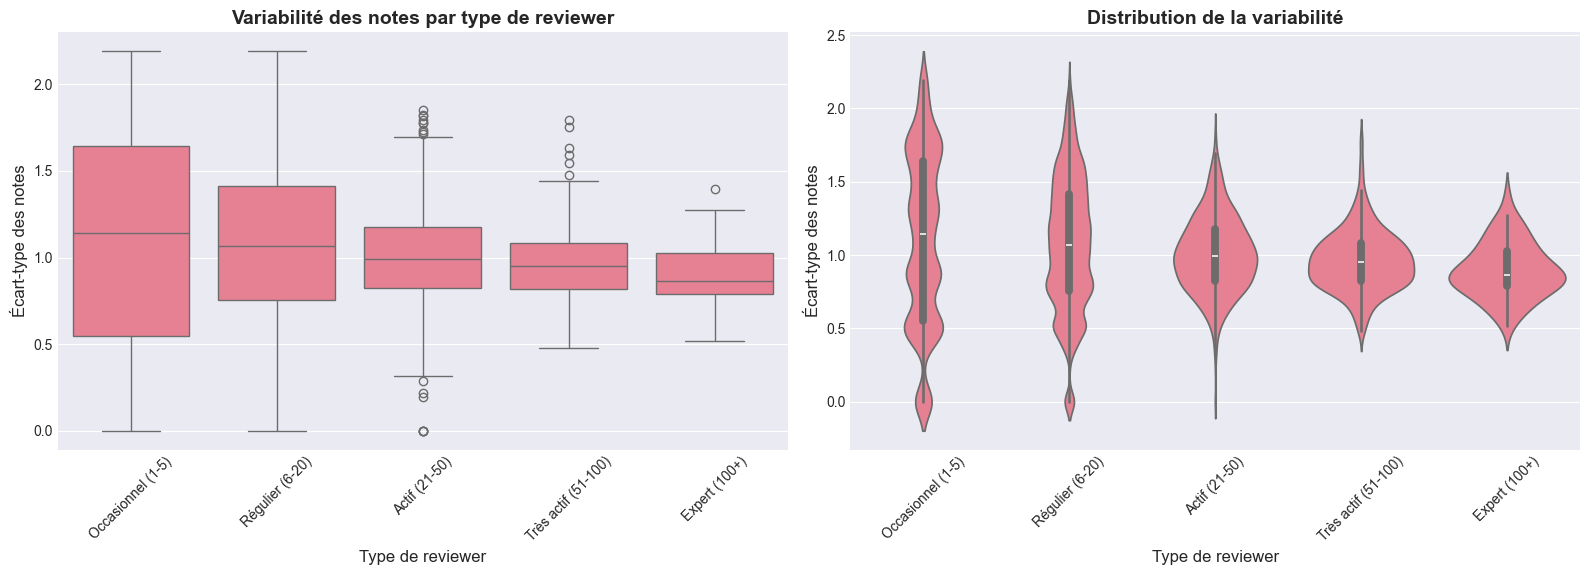

In [ ]:
# Visualisation de la variabilité
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(y='rating_std', x='reviewer_type', data=user_stats_filtered, ax=ax1)
ax1.set_xlabel('Type de reviewer', fontsize=12)
ax1.set_ylabel('Écart-type des notes', fontsize=12)
ax1.set_title('Variabilité des notes par type de reviewer', fontsize=14, fontweight='bold')
plt.suptitle('')
ax1.tick_params(axis='x', rotation=45)

# Violin plot
sns.violinplot(data=user_stats_filtered, x='reviewer_type', y='rating_std', ax=ax2)
ax2.set_xlabel('Type de reviewer', fontsize=12)
ax2.set_ylabel('Écart-type des notes', fontsize=12)
ax2.set_title('Distribution de la variabilité', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../../figures/reviewer_consistency.png', dpi=300, bbox_inches='tight')
plt.show()

### Interprétation - Variabilité des notes
La variabilité des notes (mesurée par l'écart-type) nous renseigne sur la "stabilité" des jugements des utilisateurs :
* **Stabilité accrue chez les experts** : On observe une diminution constante de l'écart-type à mesure que le nombre de reviews augmente. Les experts ont un écart-type moyen de ~0.90 contre ~1.11 pour les occasionnels.
* **Signification** : Les experts semblent avoir des critères de notation plus standardisés. Ils sont moins sujets à des notes extrêmes (très bonnes ou très mauvaises) de manière aléatoire, ou bien ils ont acquis une grille d'évaluation interne plus cohérente.
* **Éducation du goût** : Cette tendance confirme que l'expérience sur la plateforme affine non seulement la capacité de rédaction, mais aussi la justesse et la constance du jugement.

## 4. Conclusions

### Synthèse de l'analyse des reviewers :

1.  **Les "gros reviewers" sont-ils plus sévères ?**
    *   **Résultat** : Non, au contraire. Les utilisateurs experts (100+ reviews) ont une note moyenne significativement plus élevée (**3.87**) que les occasionnels (**3.68**).
    *   **Test** : Le test de Mann-Whitney confirme cette différence avec une p-value de 0.019.
    *   **Conclusion** : L'expérience sur Yelp ne rend pas les utilisateurs aigris. Ils semblent soit mieux choisir leurs établissements, soit adopter une attitude plus positive et constructive avec le temps.

2.  **Les utilisateurs expérimentés font-ils des reviews plus détaillées ?**
    *   **Résultat** : Oui, très nettement. La longueur moyenne passe de **93 mots** pour les débutants à plus de **187 mots** pour les experts.
    *   **Quantification** : Les experts écrivent des avis **100% plus longs** (le double du volume de texte).
    *   **Conclusion** : Il y a un véritable "apprentissage" de la rédaction. Les experts s'investissent davantage dans l'argumentation de leurs notes, fournissant ainsi plus de valeur ajoutée à la plateforme.

3.  **Les experts sont-ils plus consistants ?**
    *   **Résultat** : Oui. L'écart-type des notes diminue progressivement avec l'expérience (de **1.11** à **0.89**).
    *   **Interprétation** : Les experts ont des critères d'évaluation plus stables et standardisés. Ils sont moins imprévisibles dans leurs notations, ce qui suggère une professionnalisation de leur rôle de critique amateur.

**En résumé**, le profil de l'expert Yelp se dessine comme un contributeur **plus généreux**, **beaucoup plus prolixe** et **plus cohérent** dans ses jugements que l'utilisateur occasionnel.